In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Colab \Notebooks/microscopy_self_supervised_learning/microscopy_self_supervised_learning/

/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/microscopy_self_supervised_learning


Imports

In [ ]:
#!pip install umap

ERROR: Could not find a version that satisfies the requirement umap (from versions: none)
ERROR: No matching distribution found for umap


In [ ]:
import os
import numpy as np
import pandas as pd

import tifffile as tiff
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision.models import resnet18
from sklearn.manifold import TSNE
#import umap

from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
!pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 44.3 MB/s eta 0:00:00


In [ ]:
import timm

Paths & Metadata

In [ ]:
DATA_DIR = "data/raw"
RESULTS_DIR = "results/figures"
PROCESSED_DIR = "data/processed"
os.makedirs(RESULTS_DIR, exist_ok=True)

In [ ]:
X = np.load("data/splits/X_images.npy")
y = np.load("data/splits/y_labels.npy")

print(X.shape)
print(y.shape)

(3845, 3, 128, 128)
(3845, 3)


Dataset + Augmentation

In [ ]:
import torch
from torch.utils.data import Dataset
import numpy as np

def augment(x):
    if np.random.rand() < 0.5:
        x = np.flip(x, axis=2).copy()
    if np.random.rand() < 0.5:
        x = np.flip(x, axis=1).copy()

    if np.random.rand() < 0.5:
        x = x + np.random.normal(0, 0.02, x.shape)

    if np.random.rand() < 0.5:
        x = x * np.random.uniform(0.8, 1.2)

    x = np.clip(x, 0, 1)
    return x


class DINODataset(Dataset):
    def __init__(self, X):
        self.X = X

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]

        x1 = augment(img)
        x2 = augment(img)

        x1 = torch.tensor(x1, dtype=torch.float32)
        x2 = torch.tensor(x2, dtype=torch.float32)

        # normalize [-1,1]
        x1 = (x1 - 0.5) / 0.5
        x2 = (x2 - 0.5) / 0.5

        return x1, x2

Backbone + Projection Head

In [ ]:
import timm
import torch.nn as nn
import torch.nn.functional as F

class DINOHead(nn.Module):
    def __init__(self, in_dim, out_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.GELU(),
            nn.Linear(512, out_dim)
        )

    def forward(self, x):
        x = self.mlp(x)
        return F.normalize(x, dim=-1)


class DINOModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            "vit_small_patch16_224",
            pretrained=False,
            img_size=128,
            in_chans=3,
            num_classes=0
        )

        dim = self.backbone.num_features

        self.head = DINOHead(dim)

Teacher = EMA copy

In [ ]:
import copy

student = DINOModel()
teacher = copy.deepcopy(student)

for p in teacher.parameters():
    p.requires_grad = False

DINO loss (core)

In [ ]:
class DINOLoss(nn.Module):
    def __init__(self, out_dim=256, teacher_temp=0.04, student_temp=0.1):
        super().__init__()

        self.teacher_temp = teacher_temp
        self.student_temp = student_temp

        self.register_buffer("center", torch.zeros(1, out_dim))  # ✅ FIX

    def forward(self, student_out, teacher_out):

        student_out = student_out / self.student_temp
        teacher_out = (teacher_out - self.center) / self.teacher_temp

        teacher_out = F.softmax(teacher_out, dim=-1).detach()
        student_log = F.log_softmax(student_out, dim=-1)

        loss = - (teacher_out * student_log).sum(dim=-1).mean()

        # update center
        self.center = 0.9 * self.center + 0.1 * teacher_out.mean(dim=0, keepdim=True)

        return loss

Training loop

In [ ]:
from torch.utils.data import DataLoader
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

student = student.to(device)
teacher = teacher.to(device)

dataset = DINODataset(X)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

optimizer = torch.optim.AdamW(student.parameters(), lr=1e-4)
loss_fn = DINOLoss().to(device)

num_epochs = 100
momentum = 0.996   # EMA

In [ ]:
losses = []

for epoch in range(num_epochs):

    total_loss = 0
    student.train()

    for x1, x2 in tqdm(loader):

        x1 = x1.to(device)
        x2 = x2.to(device)

        # student outputs
        s1 = student.head(student.backbone(x1))
        s2 = student.head(student.backbone(x2))

        # teacher outputs
        with torch.no_grad():
            t1 = teacher.head(teacher.backbone(x1))
            t2 = teacher.head(teacher.backbone(x2))

        loss = loss_fn(s1, t2) + loss_fn(s2, t1)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # EMA update
        with torch.no_grad():
            for ps, pt in zip(student.parameters(), teacher.parameters()):
                pt.data = momentum * pt.data + (1 - momentum) * ps.data

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

100%|██████████| 61/61 [00:36<00:00,  1.66it/s]


Epoch 1, Loss: 8.3487


100%|██████████| 61/61 [00:37<00:00,  1.64it/s]


Epoch 2, Loss: 7.3838


100%|██████████| 61/61 [00:36<00:00,  1.65it/s]


...

Epoch 98, Loss: 0.2098


100%|██████████| 61/61 [00:37<00:00,  1.64it/s]


Epoch 99, Loss: 0.3113


100%|██████████| 61/61 [00:37<00:00,  1.64it/s]

Epoch 100, Loss: 0.2977


Extract embeddings

In [ ]:
def extract_embeddings(model, X):

    model.eval()
    embeddings = []

    with torch.no_grad():
        for i in range(0, len(X), 64):

            batch = torch.tensor(X[i:i+64], dtype=torch.float32).to(device)
            batch = (batch - 0.5) / 0.5

            z = model.backbone(batch)
            embeddings.append(z.cpu())

    return torch.cat(embeddings, dim=0).numpy()

In [ ]:
embeddings = extract_embeddings(student, X)
print(embeddings.shape)

(3845, 384)


In [ ]:
moa = y[:,0]
compound = y[:, 1]
concentration = y[:, 2]

In [ ]:
replicate_groups = np.array([
    f"{c}_{d}" for c, d in zip(compound, concentration)
])

In [ ]:
ssl_df = pd.DataFrame(embeddings, columns=[f"PC{i}" for i in range(1, embeddings.shape[1] + 1)])
ssl_df["moa"] = moa
ssl_df["compound"] = compound
ssl_df["concentration"] = concentration

ssl_df.to_csv("ssl_dino_embeddings.csv", index=False)

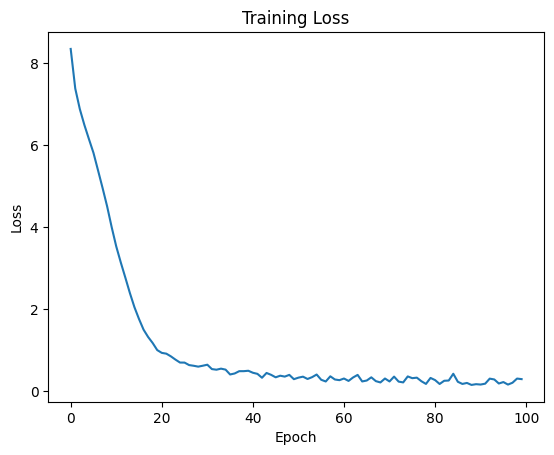

In [ ]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

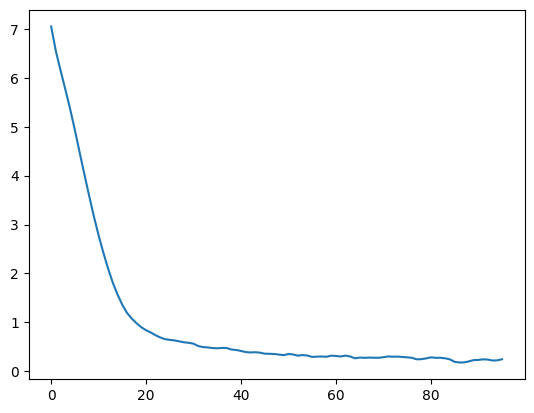

In [ ]:
def smooth(x, k=5):
    return np.convolve(x, np.ones(k)/k, mode='valid')

plt.plot(smooth(losses))

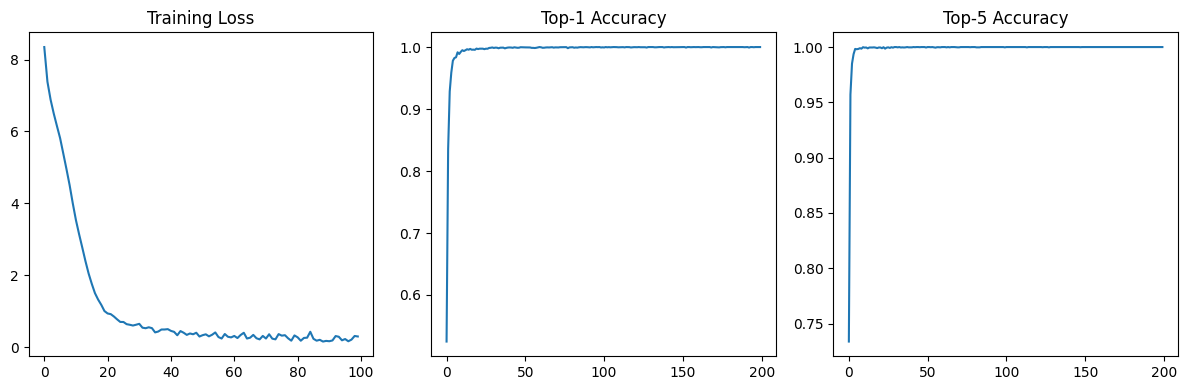

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,3,1)
plt.plot(losses)
plt.title("Training Loss")

# Top1
plt.subplot(1,3,2)
plt.plot(top1_list)
plt.title("Top-1 Accuracy")

# Top5
plt.subplot(1,3,3)
plt.plot(top5_list)
plt.title("Top-5 Accuracy")

plt.tight_layout()
plt.show()

In [ ]:
ssl_df = pd.read_csv("data/processed/ssl_dino_embeddings.csv")

print(ssl_df.shape)

(3845, 387)


In [ ]:
X_embeddings = ssl_df.drop(columns=["moa", "compound", "concentration"]).values

In [ ]:
from sklearn.preprocessing import normalize
X_embeddings = normalize(X_embeddings)

UMAP Visualization

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(moa)

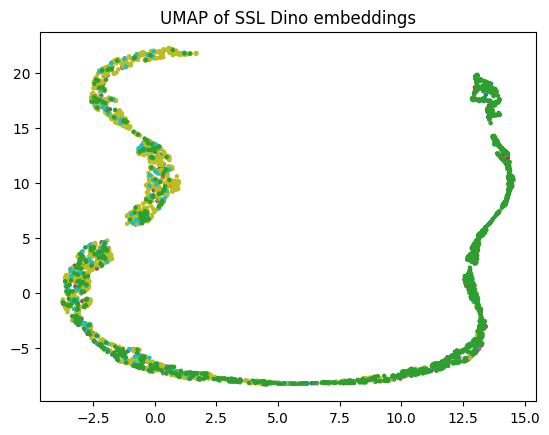

In [ ]:
import umap

reducer = umap.UMAP(n_components=2)
emb_2d = reducer.fit_transform(X_embeddings)

plt.scatter(emb_2d[:,0], emb_2d[:,1], c=y_encoded, cmap="tab10", s=5)
plt.title("UMAP of SSL Dino embeddings")
plt.savefig(os.path.join(RESULTS_DIR, "UMAP of SSL Dino embeddings.png"), dpi=300, bbox_inches="tight")
plt.show()

MOA prediction (kNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

k_values = range(1, 31)

results = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(knn, X_embeddings, y_encoded, cv=5)

    mean_score = scores.mean()

    results.append(mean_score)

    print(f"k = {k}, accuracy = {mean_score:.4f}")

k = 1, accuracy = 0.4372
k = 2, accuracy = 0.4125
k = 3, accuracy = 0.4793
k = 4, accuracy = 0.5225
k = 5, accuracy = 0.5488
k = 6, accuracy = 0.5605
k = 7, accuracy = 0.5664
k = 8, accuracy = 0.5730
k = 9, accuracy = 0.5821
k = 10, accuracy = 0.5880
k = 11, accuracy = 0.5909
k = 12, accuracy = 0.5953
k = 13, accuracy = 0.5992
k = 14, accuracy = 0.5992
k = 15, accuracy = 0.5953
k = 16, accuracy = 0.5979
k = 17, accuracy = 0.5977
k = 18, accuracy = 0.5974
k = 19, accuracy = 0.6000
k = 20, accuracy = 0.5984
k = 21, accuracy = 0.5987
k = 22, accuracy = 0.6005
k = 23, accuracy = 0.6005
k = 24, accuracy = 0.6034
k = 25, accuracy = 0.6023
k = 26, accuracy = 0.6018
k = 27, accuracy = 0.6016
k = 28, accuracy = 0.6018
k = 29, accuracy = 0.6021
k = 30, accuracy = 0.6029


In [ ]:
best_k = k_values[np.argmax(results)]
best_score = max(results)

print("Best k:", best_k)
print("Best accuracy:", best_score)

Best k: 24
Best accuracy: 0.6033810143042913


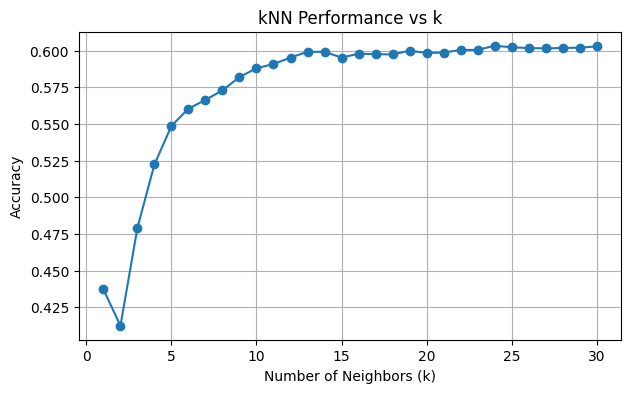

In [ ]:
plt.figure(figsize=(7,4))

plt.plot(k_values, results, marker='o')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("kNN Performance vs k")

plt.grid(True)
plt.savefig(os.path.join(RESULTS_DIR, "kNN Performance vs k for Dino in MOA prediction.png"), dpi=300, bbox_inches="tight")

plt.show()

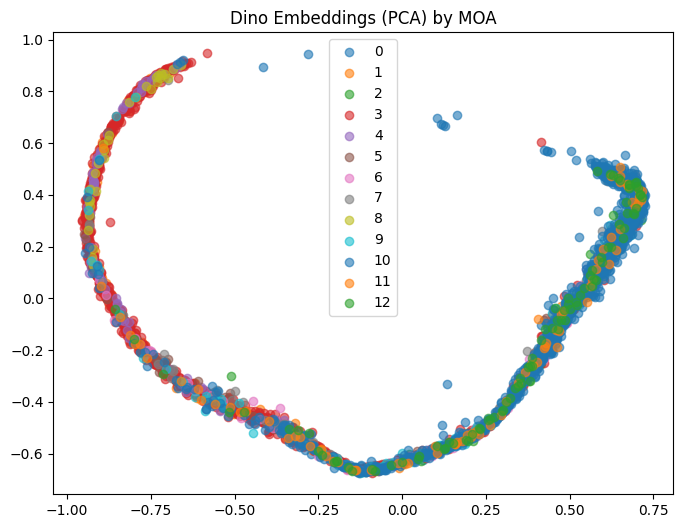

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(X_embeddings)

plt.figure(figsize=(8,6))

for moa in np.unique(y_encoded):
    idx = y_encoded == moa
    plt.scatter(emb_2d[idx, 0], emb_2d[idx, 1], label=str(moa), alpha=0.6)

plt.legend()
plt.title("Dino Embeddings (PCA) by MOA")
plt.savefig(os.path.join(RESULTS_DIR, "Dino Embeddings (PCA) by MOA.png"), dpi=300, bbox_inches="tight")
plt.show()

LOCO (Leave-One-Compound-Out)

In [ ]:
compound_ids = y[:,1]
compound_enc = LabelEncoder().fit_transform(compound)

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

logo = LeaveOneGroupOut()

k_values = range(1, 31)   # test k from 1 to 30
k_scores = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")

    scores = []

    for train_idx, test_idx in logo.split(X_embeddings, y_encoded, groups=compound_ids):

        X_train, X_test = X_embeddings[train_idx], X_embeddings[test_idx]
        y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

        knn.fit(X_train, y_train)

        acc = knn.score(X_test, y_test)

        scores.append(acc)

    mean_score = np.mean(scores)
    k_scores.append(mean_score)

    print(f"k = {k}, LOCO accuracy = {mean_score:.4f}")

k = 1, LOCO accuracy = 0.0720
k = 2, LOCO accuracy = 0.0531
k = 3, LOCO accuracy = 0.0517
k = 4, LOCO accuracy = 0.0456
k = 5, LOCO accuracy = 0.0471
k = 6, LOCO accuracy = 0.0436
k = 7, LOCO accuracy = 0.0399
k = 8, LOCO accuracy = 0.0399
k = 9, LOCO accuracy = 0.0396
k = 10, LOCO accuracy = 0.0410
k = 11, LOCO accuracy = 0.0411
k = 12, LOCO accuracy = 0.0411
k = 13, LOCO accuracy = 0.0414
k = 14, LOCO accuracy = 0.0423
k = 15, LOCO accuracy = 0.0437
k = 16, LOCO accuracy = 0.0431
k = 17, LOCO accuracy = 0.0426
k = 18, LOCO accuracy = 0.0437
k = 19, LOCO accuracy = 0.0437
k = 20, LOCO accuracy = 0.0423
k = 21, LOCO accuracy = 0.0425
k = 22, LOCO accuracy = 0.0421
k = 23, LOCO accuracy = 0.0434
k = 24, LOCO accuracy = 0.0431
k = 25, LOCO accuracy = 0.0419
k = 26, LOCO accuracy = 0.0427
k = 27, LOCO accuracy = 0.0412
k = 28, LOCO accuracy = 0.0425
k = 29, LOCO accuracy = 0.0434
k = 30, LOCO accuracy = 0.0433


In [ ]:
best_k = k_values[np.argmax(k_scores)]
best_score = max(k_scores)

print("Best k:", best_k)
print("Best LOCO accuracy:", best_score)

Best k: 1
Best LOCO accuracy: 0.07198682076730857


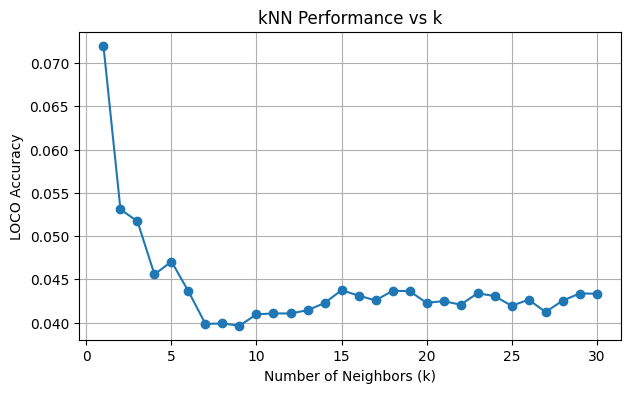

In [ ]:
plt.figure(figsize=(7,4))

plt.plot(k_values, k_scores, marker='o')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("LOCO Accuracy")
plt.title("kNN Performance vs k")
plt.savefig(os.path.join(RESULTS_DIR, "Dino LOCO kNN Performance vs k"), dpi=300, bbox_inches="tight")
plt.grid(True)

plt.show()

In [ ]:
compound_names = y[:,1]
compound_ids = LabelEncoder().fit_transform(compound_names)

In [ ]:
le_comp = LabelEncoder()
compound_encoded = le_comp.fit_transform(compound_ids)

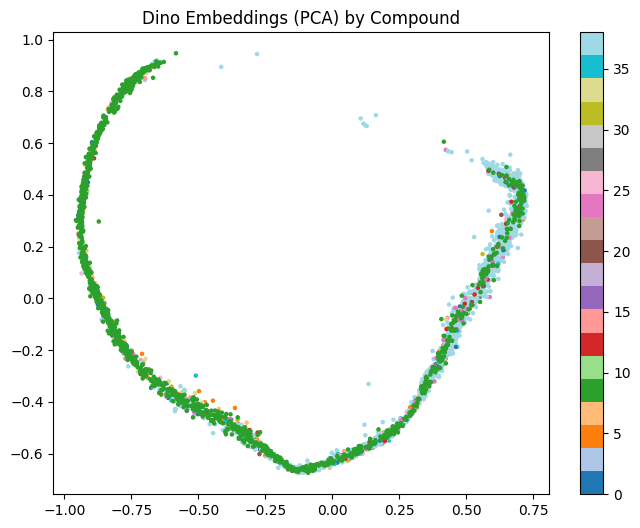

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    emb_2d[:,0],
    emb_2d[:,1],
    c=compound_encoded,   # ✅ numeric now
    cmap="tab20",
    s=5
)

plt.title("Dino Embeddings (PCA) by Compound")
plt.savefig(os.path.join(RESULTS_DIR, "Dino Embeddings (PCA) by Compound"), dpi=300, bbox_inches="tight")
plt.colorbar()
plt.show()

Replicate prediction

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
def percent_replicating(embeddings, replicate_groups):

    sim = cosine_similarity(embeddings)

    replicate_scores = []
    null_scores = []

    n = len(replicate_groups)

    for i in range(n):
        for j in range(i+1, n):

            if replicate_groups[i] == replicate_groups[j]:
                replicate_scores.append(sim[i, j])
            else:
                null_scores.append(sim[i, j])

    threshold = np.percentile(null_scores, 95)

    replicating = np.sum(np.array(replicate_scores) > threshold)

    percent = replicating / len(replicate_scores)

    return percent

In [ ]:
dino_rep = percent_replicating(X_embeddings, replicate_groups)


print("PCA percent replicating:", dino_rep)

PCA percent replicating: 0.09288407479104407
